Bibliotekos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

Duomenys

In [2]:
meteo_data = pd.read_csv("Meteo_nauji.csv", sep = ',')
meteo_data.head(5)

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation,snowDepth,conditionCode
0,2017-11-01 00:00:00,0.7,-2.5,2.8,6.0,312.0,88.0,1012.1,90.0,0.0,0.0,cloudy
1,2017-11-01 01:00:00,0.4,0.4,0.8,3.5,309.0,88.0,1012.4,91.0,0.0,0.0,cloudy
2,2017-11-01 02:00:00,0.8,0.8,1.0,3.2,247.0,100.0,1012.4,91.0,0.0,0.0,cloudy
3,2017-11-01 03:00:00,0.7,0.7,1.3,3.9,259.0,88.0,1012.3,92.0,0.0,0.0,cloudy
4,2017-11-01 04:00:00,0.5,-2.4,2.5,3.9,238.0,88.0,1011.9,93.0,0.0,0.0,cloudy


In [3]:
meteo_data.shape

(73028, 12)

Duomenų tvarkymas ir paruošimas

In [4]:
clean_meteo_data = meteo_data.drop(columns = ['snowDepth', 'conditionCode'])
clean_meteo_data['observationTimeUtc'] = pd.to_datetime(clean_meteo_data['observationTimeUtc'])
clean_meteo_data.shape

(73028, 10)

Praleistos reikšmės

In [5]:
clean_meteo_data.isnull().sum()

observationTimeUtc         0
airTemperature            58
feelsLikeTemperature      93
windSpeed                 92
windGust                 138
windDirection             87
cloudCover              1605
seaLevelPressure          68
relativeHumidity          71
precipitation             22
dtype: int64

In [6]:
station_year = clean_meteo_data["observationTimeUtc"].dt.year.unique()
station_year.sort()
nan_year_result = []
for year in station_year:
    nan_year_result.append(clean_meteo_data[clean_meteo_data["observationTimeUtc"].dt.year == year].isnull().sum())
nan_year_Vilnius = pd.DataFrame(nan_year_result, index = station_year)
nan_year_Vilnius

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation
2017,0,0,0,0,0,0,25,0,0,0
2018,0,0,2,2,8,0,173,1,0,1
2019,0,0,1,1,5,0,130,0,0,3
2020,0,15,20,19,38,18,307,17,18,0
2021,0,0,0,0,1,0,149,0,0,0
2022,0,0,0,0,1,0,270,0,0,0
2023,0,0,0,0,0,0,111,0,0,0
2024,0,32,49,49,53,48,151,32,32,0
2025,0,11,21,21,30,21,263,18,21,18
2026,0,0,0,0,2,0,26,0,0,0


In [7]:
clean_meteo_data.groupby(clean_meteo_data['observationTimeUtc'].dt.year)['observationTimeUtc'].apply(lambda x: x.dt.date.nunique())

observationTimeUtc
2017     61
2018    365
2019    365
2020    366
2021    365
2022    365
2023    365
2024    366
2025    365
2026     60
Name: observationTimeUtc, dtype: int64

Praleisti stebėjimai pagal požymį

In [8]:
pd.set_option('display.max_rows', 500)
clean_meteo_data[clean_meteo_data['precipitation'].isnull()]

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation
3973,2018-04-15 13:00:00,18.0,18.0,4.8,NaN,166.0,NaN,1021.9,44.0,NaN
10688,2019-01-20 12:00:00,-1.7,NaN,NaN,NaN,237.0,100.0,1013.6,92.0,NaN
10997,2019-02-02 09:00:00,1.1,-3.6,5.0,9.0,123.0,100.0,1008.3,96.0,NaN
10998,2019-02-02 10:00:00,1.4,-3.2,5.1,9.5,138.0,100.0,1008.0,94.0,NaN
71076,2025-12-10 16:00:00,7.5,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN
71077,2025-12-10 17:00:00,8.0,NaN,NaN,NaN,NaN,NaN,1014.5,NaN,NaN
71078,2025-12-10 18:00:00,8.5,NaN,NaN,NaN,NaN,NaN,1014.4,NaN,NaN
71079,2025-12-10 19:00:00,8.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71082,2025-12-10 22:00:00,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71492,2025-12-28 00:00:00,0.8,-4.6,6.3,NaN,306.0,100.0,1001.7,91.0,NaN


Duomenų aibės agregavimas

In [9]:
agg_logic = {
    'airTemperature': 'mean',
    'feelsLikeTemperature': 'mean',
    'windSpeed': 'mean',
    'windGust': 'max',
    'windDirection': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
    'cloudCover': 'mean',
    'seaLevelPressure': 'mean',
    'relativeHumidity': 'mean',
    'precipitation': 'sum'
}

agg_meteo_data = clean_meteo_data.groupby(clean_meteo_data["observationTimeUtc"].dt.date).agg(agg_logic)
agg_meteo_data = agg_meteo_data.reset_index()
agg_meteo_data["observationTimeUtc"] = pd.to_datetime(agg_meteo_data["observationTimeUtc"])
agg_meteo_data

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation
0,2017-11-01,4.441667,2.400000,2.820833,10.0,252.0,96.500000,1007.975000,94.125000,7.5
1,2017-11-02,8.387500,6.783333,2.825000,9.3,242.0,94.000000,1000.504167,95.500000,12.2
2,2017-11-03,7.116667,5.566667,2.454167,7.8,38.0,95.500000,1010.212500,94.541667,1.1
3,2017-11-04,6.275000,4.245833,2.812500,6.4,210.0,95.000000,1017.562500,93.083333,0.0
4,2017-11-05,6.037500,3.204167,3.891667,9.5,159.0,71.708333,1015.170833,87.583333,0.0
...,...,...,...,...,...,...,...,...,...,...
3038,2026-02-25,-1.991667,-4.641667,2.229167,9.2,315.0,99.000000,1022.991667,84.791667,0.3
3039,2026-02-26,-2.100000,-5.512500,3.191667,8.5,164.0,69.416667,1029.512500,77.541667,0.0
3040,2026-02-27,0.250000,-3.962500,4.008333,9.4,179.0,70.000000,1023.262500,76.000000,0.0
3041,2026-02-28,3.491667,0.883333,2.766667,5.3,161.0,15.208333,1021.162500,76.083333,0.0


In [10]:
agg_meteo_data.isnull().sum()

observationTimeUtc       0
airTemperature           0
feelsLikeTemperature     2
windSpeed                2
windGust                 2
windDirection            1
cloudCover              11
seaLevelPressure         0
relativeHumidity         0
precipitation            0
dtype: int64

In [11]:
agg_meteo_data[agg_meteo_data['cloudCover'].isnull()]

,observationTimeUtc,airTemperature,feelsLikeTemperature,windSpeed,windGust,windDirection,cloudCover,seaLevelPressure,relativeHumidity,precipitation
1127,2020-12-02,-2.933333,-4.638889,1.500000,4.3,140.0,NaN,1028.505556,90.944444,0.0
1128,2020-12-03,-0.704167,-5.337500,4.558333,17.0,148.0,NaN,1021.170833,89.791667,0.0
1129,2020-12-04,1.175000,-4.533333,7.300000,15.4,144.0,NaN,1016.083333,90.333333,0.0
1130,2020-12-05,2.562500,-2.487500,6.629167,14.0,140.0,NaN,1020.279167,93.833333,0.0
1131,2020-12-06,0.750000,-4.950000,7.025000,15.0,138.0,NaN,1025.525000,76.625000,0.0
1522,2022-01-01,1.887500,-2.004167,4.220833,15.4,275.0,NaN,1012.729167,91.291667,0.3
1523,2022-01-02,-1.895833,-5.941667,3.870833,14.5,166.0,NaN,1012.416667,94.916667,10.6
1524,2022-01-03,3.958333,0.754167,3.829167,12.4,301.0,NaN,996.375000,97.375000,6.0
2390,2024-05-18,16.437500,NaN,NaN,NaN,50.0,NaN,1016.912500,71.625000,1.3
2391,2024-05-19,15.925000,NaN,NaN,NaN,NaN,NaN,1014.575000,73.250000,0.3


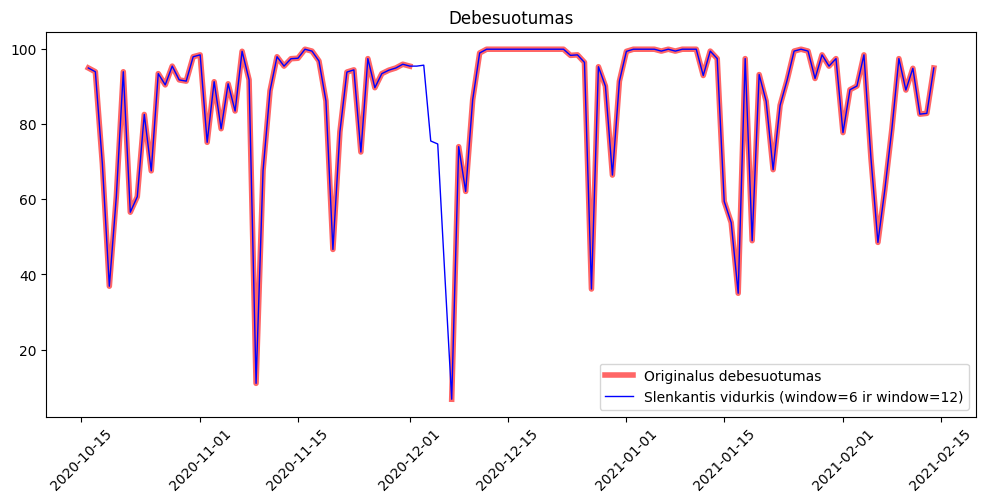

In [12]:
agg_meteo_data_copy = agg_meteo_data.copy()

smooth_values1 = agg_meteo_data_copy['cloudCover'].rolling(window=6, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed'] = agg_meteo_data_copy['cloudCover'].fillna(smooth_values1)

smooth_values2 = agg_meteo_data_copy['cloudCover_fixed'].rolling(window=12, min_periods=2, center=True).mean()
agg_meteo_data_copy['cloudCover_fixed'] = agg_meteo_data_copy['cloudCover_fixed'].fillna(smooth_values2)

time_mask = (agg_meteo_data['observationTimeUtc'] > '2020-10-15') & (agg_meteo_data['observationTimeUtc'] < '2021-02-15')
filtered_data = agg_meteo_data_copy[time_mask]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(filtered_data['observationTimeUtc'], filtered_data['cloudCover'], label='Originalus debesuotumas', color='red', linewidth=4, alpha=0.6)
ax.plot(filtered_data['observationTimeUtc'], filtered_data['cloudCover_fixed'], label='Slenkantis vidurkis (window=6 ir window=12)', color='blue', linewidth=1)
ax.set_title('Debesuotumas')
ax.legend()
plt.xticks(rotation=45)
plt.show()

Praleistų reikšmių įrašymas

In [13]:
# agg_meteo_data_smoothing = agg_meteo_data_copy['cloudCover'].rolling(window=10, min_periods=2, center=True).mean()

# agg_meteo_data_smoothing = agg_meteo_data.select_dtypes(include='number').rolling(window=4, min_periods=2, center=True).mean()
# agg_meteo_data_smoothing.isnull().sum()

In [14]:
# agg_meteo_data_smoothing['observationTimeUtc'] = agg_meteo_data['observationTimeUtc']

In [15]:
# agg_meteo_data_smoothing[agg_meteo_data_smoothing['cloudCover'].isnull()]

Duomenų įrašymas

In [16]:
# agg_meteo_data_smoothing.to_csv('Vilnius_meteo_data_new_2017_2026.csv', index=False, encoding='utf-8-sig')